In [183]:
print("hello")

hello


In [184]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

In [185]:
df = pd.read_csv("./archive/Loan Prediction.csv")

In [186]:
df.head(10)

,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0
2,3,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4,10,0
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1
4,5,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1
5,6,6915937,64,0,single,rented,no,Civil_servant,Jalgaon,Maharashtra,0,12,0
6,7,3954973,58,14,married,rented,no,Librarian,Tiruppur,Tamil_Nadu,8,12,0
7,8,1706172,33,2,single,rented,no,Economist,Jamnagar,Gujarat,2,14,0
8,9,7566849,24,17,single,rented,yes,Flight_attendant,Kota[6],Rajasthan,11,11,0
9,10,8964846,23,12,single,rented,no,Architect,Karimnagar,Telangana,5,13,0


In [187]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252000 entries, 0 to 251999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Id                 252000 non-null  int64 
 1   Income             252000 non-null  int64 
 2   Age                252000 non-null  int64 
 3   Experience         252000 non-null  int64 
 4   Married/Single     252000 non-null  object
 5   House_Ownership    252000 non-null  object
 6   Car_Ownership      252000 non-null  object
 7   Profession         252000 non-null  object
 8   CITY               252000 non-null  object
 9   STATE              252000 non-null  object
 10  CURRENT_JOB_YRS    252000 non-null  int64 
 11  CURRENT_HOUSE_YRS  252000 non-null  int64 
 12  Risk_Flag          252000 non-null  int64 
dtypes: int64(7), object(6)
memory usage: 25.0+ MB


Id                   0
Income               0
Age                  0
Experience           0
Married/Single       0
House_Ownership      0
Car_Ownership        0
Profession           0
CITY                 0
STATE                0
CURRENT_JOB_YRS      0
CURRENT_HOUSE_YRS    0
Risk_Flag            0
dtype: int64

In [188]:
import seaborn as sns

<Axes: xlabel='Risk_Flag', ylabel='count'>

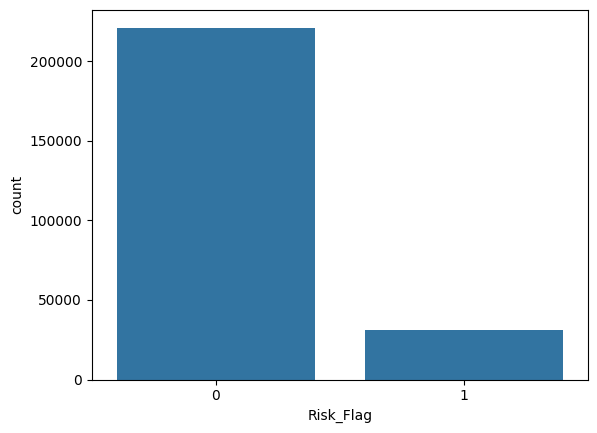

In [189]:
sns.countplot(x="Risk_Flag" , data =df)

In [190]:
print(df['CITY'].nunique())
df['STATE'].nunique()

317


29

In [191]:
df["Car_Ownership"].unique()

array(['no', 'yes'], dtype=object)

In [192]:
df["Married/Single"] = df["Married/Single"].map({"single" : 0 , "married" :1})

df["Car_Ownership"] = df["Car_Ownership"].map({"no" : 0 , "yes" :1}) 


In [193]:

df["Profession"].unique()

array(['Mechanical_engineer', 'Software_Developer', 'Technical_writer',
       'Civil_servant', 'Librarian', 'Economist', 'Flight_attendant',
       'Architect', 'Designer', 'Physician', 'Financial_Analyst',
       'Air_traffic_controller', 'Politician', 'Police_officer', 'Artist',
       'Surveyor', 'Design_Engineer', 'Chemical_engineer',
       'Hotel_Manager', 'Dentist', 'Comedian', 'Biomedical_Engineer',
       'Graphic_Designer', 'Computer_hardware_engineer',
       'Petroleum_Engineer', 'Secretary', 'Computer_operator',
       'Chartered_Accountant', 'Technician', 'Microbiologist',
       'Fashion_Designer', 'Aviator', 'Psychologist', 'Magistrate',
       'Lawyer', 'Firefighter', 'Engineer', 'Official', 'Analyst',
       'Geologist', 'Drafter', 'Statistician', 'Web_designer',
       'Consultant', 'Chef', 'Army_officer', 'Surgeon', 'Scientist',
       'Civil_engineer', 'Industrial_Engineer', 'Technology_specialist'],
      dtype=object)

In [194]:
df.columns

Index(['Id', 'Income', 'Age', 'Experience', 'Married/Single',
       'House_Ownership', 'Car_Ownership', 'Profession', 'CITY', 'STATE',
       'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS', 'Risk_Flag'],
      dtype='object')

In [195]:
df = df.drop(["Id", "CITY", "STATE", "Profession"], axis=1)

In [197]:
X = df[['Income', 'Age', 'Experience', 'Married/Single',
       'House_Ownership_norent_noown', 'House_Ownership_owned',
       'House_Ownership_rented', 'Car_Ownership', 
       'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS']]

y = df["Risk_Flag"]

KeyError: "['House_Ownership_norent_noown', 'House_Ownership_owned', 'House_Ownership_rented'] not in index"

In [198]:
df = pd.get_dummies(df , columns =["House_Ownership"] , dtype =int)

In [199]:

df.columns

Index(['Income', 'Age', 'Experience', 'Married/Single', 'Car_Ownership',
       'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS', 'Risk_Flag',
       'House_Ownership_norent_noown', 'House_Ownership_owned',
       'House_Ownership_rented'],
      dtype='object')

In [202]:
y

0         0
1         0
2         0
3         1
4         1
         ..
251995    0
251996    0
251997    0
251998    0
251999    0
Name: Risk_Flag, Length: 252000, dtype: int64

In [203]:
from sklearn.model_selection import train_test_split

In [204]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42 ,shuffle=True)

In [205]:
print(X.shape)
print(y.shape)

(252000, 10)
(252000,)


In [206]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


In [207]:
mod1=LogisticRegression()
mod2=RandomForestClassifier(max_depth=2 )


In [208]:
mod1.fit(X_train , y_train)
mod2.fit(X_train , y_train)

RandomForestClassifier(max_depth=2)

In [209]:
from sklearn.metrics import accuracy_score

In [210]:
y_pred1 = mod1.predict(X_test)
y_pred2 = mod2.predict(X_test)

In [211]:
X_test.columns.tolist()

['Income',
 'Age',
 'Experience',
 'Married/Single',
 'House_Ownership_norent_noown',
 'House_Ownership_owned',
 'House_Ownership_rented',
 'Car_Ownership',
 'CURRENT_JOB_YRS',
 'CURRENT_HOUSE_YRS']

In [ ]:
X_test = X_test[X_train.columns]

In [212]:
score1 = accuracy_score(y_test , y_pred1)
score2 = accuracy_score(y_test , y_pred2)

In [213]:
print(score1)
print(score2)

0.8759325396825397
0.8759325396825397


In [215]:
from sklearn.metrics import classification_report

In [218]:
print(classification_report(y_test  , y_pred1))
print(classification_report(y_test  , y_pred2))

              precision    recall  f1-score   support

           0       0.88      1.00      0.93     44147
           1       0.00      0.00      0.00      6253

    accuracy                           0.88     50400
   macro avg       0.44      0.50      0.47     50400
weighted avg       0.77      0.88      0.82     50400

              precision    recall  f1-score   support

           0       0.88      1.00      0.93     44147
           1       0.00      0.00      0.00      6253

    accuracy                           0.88     50400
   macro avg       0.44      0.50      0.47     50400
weighted avg       0.77      0.88      0.82     50400



c:\anaconda\envs\NLP_clg\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\anaconda\envs\NLP_clg\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\anaconda\envs\NLP_clg\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\anaconda\envs\NLP_clg\lib\site-packag

In [220]:
from imblearn.over_sampling import SMOTE

ModuleNotFoundError: No module named 'imblearn'